# Aula 02 — Métodos Baseados em Valores
## Notebook 03 — SARSA e comparação on-policy vs off-policy

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Tema:** SARSA, Q-Learning, on-policy vs off-policy  
**Ambiente:** Taxi-v3

## Informações do notebook

| Item | Detalhe |
|---|---|
| **Aula** | Aula 02 — Métodos Baseados em Valores |
| **Notebook** | 03 — SARSA e on-policy vs off-policy |
| **Seções** | 2.6 |
| **Tempo de leitura** | 16 min |
| **Tempo de execução (padrão)** | 4 min |
| **Exercícios** | 3 questões de autoavaliação |

### Pré-requisitos

- **Notebooks anteriores:** `02_mc_td_qlearning.ipynb` — Q-Learning, bootstrapping.
- **Conceitos:** Q(s,a), política ε-greedy, alvo de atualização TD.

### Competências para o Desafio Final

- Implementar SARSA e comparar curvas de aprendizado com Q-Learning no mesmo ambiente.
- Explicar a diferença entre on-policy e off-policy e quando cada um é preferível.
- Identificar por que o SARSA tende a ser mais conservador em ambientes com penalidades por exploração.

### Recapitulando

No notebook anterior, o **Q-Learning** aprendeu Q(s,a) usando um alvo off-policy: `r + γ·max Q(s', a*)`. A questão que fica: o que acontece quando o alvo inclui a ação que a política ε-greedy vai *de fato* tomar no próximo estado? Essa diferença de uma variável define o SARSA.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0
torch                2.11.0+cpu
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1
scikit-learn         1.8.0


## Bloco 1 — Contexto e pergunta



No notebook anterior, o Q-Learning aprendeu a partir da **melhor ação possível** no próximo estado — independentemente do que a política de comportamento realmente faria. Esse é o princípio *off-policy* (aprende sobre a melhor política possível).

O SARSA faz uma escolha diferente: aprende a partir da **ação que a política de comportamento efetivamente vai tomar** no próximo estado. Esse é o princípio *on-policy* (aprende sobre a política executada).

> **Qual é a diferença prática entre aprender sobre a política que está sendo executada (on-policy) e aprender sobre a política ótima idealizada (off-policy)?**

**Mensagem principal:**
> *SARSA aprende com a ação que vai tomar; Q-Learning aprende com a melhor ação possível.*

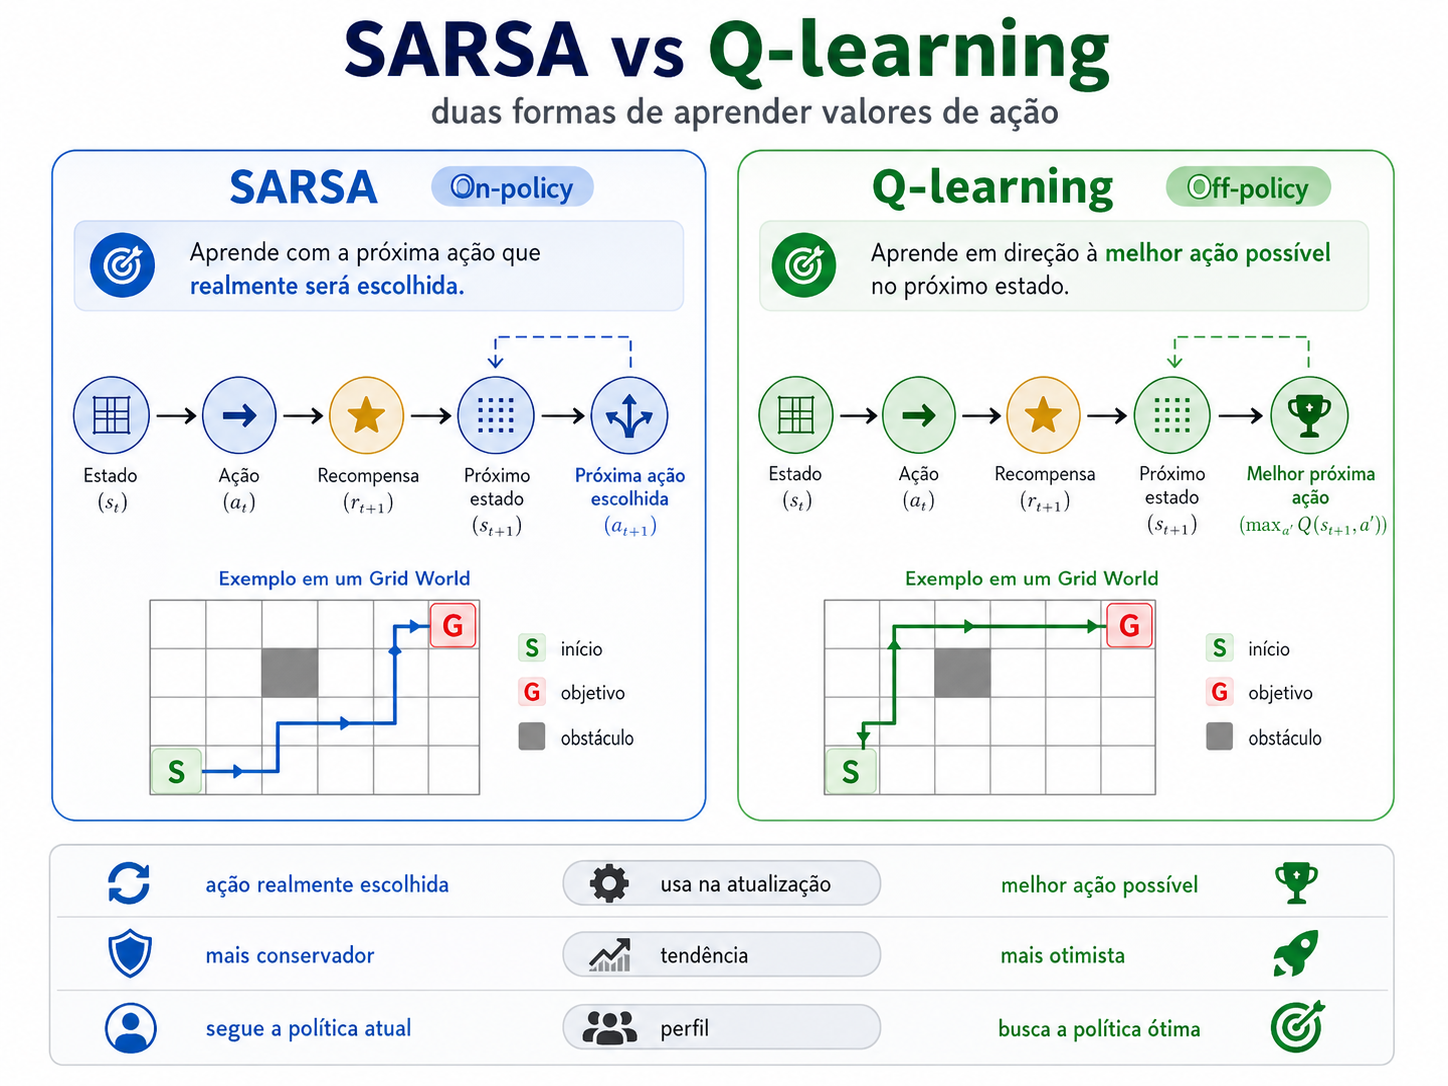

### Um exemplo prático: escolhendo o caminho para o trabalho



Imagine que você dirige todos os dias até o trabalho e existem várias rotas possíveis. Você ainda não conhece bem a cidade, então precisa testar caminhos diferentes para descobrir qual deles, em média, é o mais rápido. A cada dia, você toma decisões em vários pontos: seguir reto, virar à direita, pegar a marginal, entrar em uma rua secundária. Ao final do trajeto, o tempo total gasto funciona como o "retorno" daquela escolha de rota.

Como você ainda está aprendendo, adota uma estratégia mista: na maior parte das vezes escolhe o caminho que parece melhor com base na sua experiência, mas, de vez em quando, decide explorar uma rota nova só para ver no que dá. Essa é a sua **política de comportamento** — a forma como você efetivamente dirige no dia a dia, com um pouco de exploração misturada à rotina.

Agora vem a diferença essencial.

No estilo **SARSA (on-policy)**, você aprende com a realidade do que aconteceu. Suponha que, em determinado cruzamento, você decidiu testar uma rua nova "só para ver" e acabou caindo em um congestionamento absurdo. O SARSA registra: "naquele cruzamento, o caminho que efetivamente tomei me custou trinta minutos". A atualização é feita com base na ação que você de fato executou, exploração inclusa. O resultado é uma estimativa que reflete o seu comportamento real, com todos os desvios e experimentos que ele inclui. Por consequência, o SARSA tende a aprender rotas mais conservadoras: ele "sabe" que, na prática, você às vezes faz escolhas exploratórias arriscadas, e leva isso em conta ao avaliar cada cruzamento.

No estilo **Q-Learning (off-policy)**, você aprende como se sempre tivesse tomado a melhor decisão possível. No mesmo cenário, depois de pegar o congestionamento, o Q-Learning não atualiza pensando "a rua nova foi ruim". Ele pensa: "se eu estivesse naquele cruzamento e tivesse tomado a melhor decisão que conheço hoje, teria seguido pela avenida principal e gastado quinze minutos". A atualização é feita como se a política ótima tivesse sido seguida a partir dali, ignorando o fato de que, naquele dia específico, você decidiu explorar. O Q-Learning aprende, portanto, sobre a rota ideal — aquela que você seguiria se nunca mais experimentasse nada novo.

A diferença prática aparece com clareza quando há risco envolvido. Imagine que uma das rotas passa por uma região onde, ocasionalmente, há bloqueios imprevisíveis que aumentam muito o tempo de viagem. O SARSA, por aprender com o que de fato acontece (incluindo os dias em que você explorou e foi mal), tenderá a evitar essa região, tratando-a como perigosa. Já o Q-Learning, por aprender com base na melhor escolha possível em cada ponto, pode considerar que essa rota é ótima quando tudo dá certo — mesmo que, na prática, sua estratégia exploratória eventualmente o leve a sofrer com os bloqueios.

Em síntese: o SARSA aprende sobre o motorista que você realmente é, com seus experimentos e imperfeições. O Q-Learning aprende sobre o motorista ideal que você gostaria de ser, assumindo que, no momento da execução, todas as decisões serão ótimas.

In [2]:
# Instalação opcional das dependências
# %pip install gymnasium numpy matplotlib

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Versões utilizadas:")
print("numpy:", np.__version__)
print("gymnasium:", gym.__version__)
print("matplotlib:", plt.matplotlib.__version__)

Versões utilizadas:
numpy: 2.4.2
gymnasium: 1.0.0
matplotlib: 3.10.8


## Inspeção do ambiente

O Taxi-v3 é um problema clássico de controle tabular com espaço de estados discreto e moderado (500 estados, 6 ações). O agente precisa navegar até um passageiro, coletá-lo e entregá-lo ao destino correto. Cada passo tem penalidade, e ações ilegais (coleta/entrega errada) têm penalidade adicional. Esse ambiente torna a diferença entre on-policy e off-policy mais interessante do que ambientes simples.

In [4]:
env = gym.make("Taxi-v3")
obs, info = env.reset(seed=SEED)

print("Espaço de estados:", env.observation_space)
print("Número de estados:", env.observation_space.n)
print("Espaço de ações:", env.action_space)
print("Número de ações:", env.action_space.n)
print("Observação inicial:", obs)

nomes_acoes = {0: "Sul", 1: "Norte", 2: "Leste", 3: "Oeste",
               4: "Pegar passageiro", 5: "Deixar passageiro"}
print("\nAções disponíveis:")
for idx, nome in nomes_acoes.items():
    print(f"  {idx}: {nome}")

acao_amostra = env.action_space.sample()
prox_obs, recompensa, terminated, truncated, info = env.step(acao_amostra)
print(f"\nExemplo de transição: ação={nomes_acoes[acao_amostra]}, "
      f"obs={prox_obs}, recompensa={recompensa}")

Espaço de estados: Discrete(500)
Número de estados: 500
Espaço de ações: Discrete(6)
Número de ações: 6
Observação inicial: 386

Ações disponíveis:
  0: Sul
  1: Norte
  2: Leste
  3: Oeste
  4: Pegar passageiro
  5: Deixar passageiro

Exemplo de transição: ação=Leste, obs=386, recompensa=-1


**Decodificando o estado do Taxi-v3**

O ambiente retorna o estado como um número inteiro (ex: `obs = 386`). Esse inteiro codifica uma combinação de três variáveis:

| Variável | Opções |
|---|---|
| Posição do táxi | 25 (grade 5×5: linha × 5 + coluna) |
| Localização do passageiro | 5 (4 paradas fixas + dentro do táxi) |
| Destino | 4 (uma das 4 paradas fixas) |

Total: 25 × 5 × 4 = **500 estados** (inteiros de 0 a 499). Para decodificar qualquer estado: `gym.make("Taxi-v3").unwrapped.decode(obs)` retorna `(linha_taxi, col_taxi, passageiro, destino)`.

## Bloco 2 — Mini teoria: regras de atualização

Antes da definição formal, uma analogia que captura a diferença de caráter entre os dois algoritmos:

> **Q-Learning (off-policy):** "Aprendo a agir perfeitamente. Exploro de forma aleatória agora, mas meu alvo é sempre a política ótima futura."
> 
> **SARSA (on-policy):** "Aprendo enquanto ajo. Meu alvo inclui o fato de que cometerei erros exploratórios. Por isso aprendo a ser mais cauteloso perto de penalidades."

A diferença entre Q-Learning e SARSA está em **uma única variável** do alvo de atualização:

**Q-Learning (off-policy):**

    Q(s,a) ← Q(s,a) + α · [r + γ · max_a' Q(s',a') − Q(s,a)]

O alvo usa `max` sobre todas as ações possíveis em s' — aprende como se o agente agisse de forma totalmente gulosa a partir dali.

**SARSA (on-policy):**

    Q(s,a) ← Q(s,a) + α · [r + γ · Q(s', a') − Q(s,a)]

O alvo usa a ação `a'` que a política ε-greedy *de fato escolherá* em s' — aprende sobre o comportamento real, incluindo exploração.

**Consequência:** O SARSA internaliza o custo da exploração. Em ambientes onde ações exploratórias podem ser perigosas ou custosas, o SARSA tende a ser mais conservador.

In [5]:
print("Q-Learning (off-policy):")
print("  Q(s,a) <- Q(s,a) + α · [r + γ · max_a' Q(s',a') - Q(s,a)]")
print()
print("SARSA (on-policy):")
print("  Q(s,a) <- Q(s,a) + α · [r + γ · Q(s',a') - Q(s,a)]")
print()
print("Diferença-chave:")
print("  Q-Learning usa max Q(s', *) → aprende sobre política gulosa")
print("  SARSA usa Q(s', a') onde a' ~ política atual → aprende sobre política epsilon-greedy")

Q-Learning (off-policy):
  Q(s,a) <- Q(s,a) + α · [r + γ · max_a' Q(s',a') - Q(s,a)]

SARSA (on-policy):
  Q(s,a) <- Q(s,a) + α · [r + γ · Q(s',a') - Q(s,a)]

Diferença-chave:
  Q-Learning usa max Q(s', *) → aprende sobre política gulosa
  SARSA usa Q(s', a') onde a' ~ política atual → aprende sobre política epsilon-greedy


## Política epsilon-greedy compartilhada

Ambos os algoritmos usam a mesma estratégia de exploração epsilon-greedy. Isso mantém a comparação centrada na diferença do alvo de atualização, não em diferenças de política de comportamento.

In [6]:
def epsilon_greedy(Q, estado, epsilon, n_acoes):
    if random.random() < epsilon:
        return random.randrange(n_acoes)
    return int(np.argmax(Q[estado]))

print("Função epsilon_greedy definida.")

Função epsilon_greedy definida.


## Implementação do Q-Learning

O alvo off-policy usa `max` sobre as ações no próximo estado. A política ε-greedy é usada apenas para coletar experiência — a atualização ignora qual ação seria de fato escolhida.

In [7]:
def treinar_qlearning(env, episodios=5000, alpha=0.1, gamma=0.99,
                      eps_inicio=1.0, eps_fim=0.05, eps_decaimento=0.999):
    """
    Aprende Q(s,a) com Q-Learning off-policy e política ε-greedy.

    Parâmetros:
        env             : ambiente Gymnasium com espaços discretos
        episodios       : número total de episódios de treinamento
        alpha           : taxa de aprendizado (peso da nova informação na atualização)
        gamma           : fator de desconto (quanto o futuro vale em relação ao presente)
        eps_inicio      : valor inicial de epsilon (1.0 = 100% exploração no começo)
        eps_fim         : piso de epsilon (mantém alguma exploração até o fim)
        eps_decaimento  : multiplicador aplicado a epsilon a cada episódio
    """

    # -----------------------------------------------------------------
    # PREPARAÇÃO: dimensões do problema e estrutura de dados
    # Esta parte é IDÊNTICA ao SARSA — a diferença não está aqui.
    # -----------------------------------------------------------------
    n_s = env.observation_space.n
    n_a = env.action_space.n

    # Q[s, a] guarda a estimativa de retorno acumulado ao tomar a ação a no estado s.
    Q = np.zeros((n_s, n_a), dtype=float)

    # Listas para registrar o progresso do treinamento
    recompensas_ep = []
    passos_ep = []

    # Epsilon começa no valor de exploração inicial e vai decaindo
    eps = eps_inicio

    # -----------------------------------------------------------------
    # LAÇO PRINCIPAL: cada iteração é um episódio completo
    # -----------------------------------------------------------------
    for ep in range(episodios):
        # Reset do ambiente; a seed garante reprodutibilidade entre execuções
        estado, _ = env.reset(seed=SEED + ep)

        # =================================================================
        # *** DIFERENÇA #1 EM RELAÇÃO AO SARSA ***
        # Repare: aqui NÃO há escolha de ação antes do loop.
        # No SARSA, neste ponto teríamos:
        #     acao = epsilon_greedy(Q, estado, eps, n_a)
        # No Q-Learning, a ação só é decidida dentro do loop, no momento
        # exato em que vai ser executada. Não existe "ação pré-anunciada"
        # como no SARSA — e por isso o Q-Learning não tem um nome com
        # cinco letras descrevendo uma sequência de decisões.
        # =================================================================

        # Variáveis de controle do episódio
        encerrado = False
        total = 0.0
        passos = 0

        # -----------------------------------------------------------------
        # LAÇO INTERNO: cada iteração é um passo dentro do episódio
        # -----------------------------------------------------------------
        while not encerrado:
            # Escolha da ação a ser executada AGORA, com base na política ε-greedy.
            # Esta é a única vez que epsilon_greedy é chamada por passo no Q-Learning.
            # No SARSA, epsilon_greedy é chamada duas vezes (uma para a ação atual,
            # outra para compor o alvo) — aqui é apenas uma.
            acao = epsilon_greedy(Q, estado, eps, n_a)

            # Executa a ação no ambiente e observa o resultado
            prox_estado, recompensa, terminado, truncado, _ = env.step(acao)
            encerrado = terminado or truncado

            # =================================================================
            # *** DIFERENÇA #2 EM RELAÇÃO AO SARSA — A MAIS IMPORTANTE ***
            # Esta é a linha que define o Q-Learning. Compare:
            #
            # Q-Learning (este código):
            #     alvo = recompensa + gamma * np.max(Q[prox_estado])
            #
            # SARSA (versão equivalente):
            #     prox_acao = epsilon_greedy(Q, prox_estado, eps, n_a)
            #     alvo = recompensa + gamma * Q[prox_estado, prox_acao]
            #
            # O np.max é o que torna o Q-Learning OFF-POLICY:
            #
            # - O alvo é construído como se, no próximo estado, o agente
            #   fosse SEMPRE escolher a melhor ação conhecida — independente
            #   do que a política ε-greedy realmente fará. A exploração
            #   ainda acontece (lá em cima, na linha do epsilon_greedy),
            #   mas é completamente ignorada na hora de aprender.
            #
            # - O agente, portanto, aprende sobre a política ótima idealizada,
            #   não sobre a política que está sendo executada. Pode estar
            #   tomando decisões aleatórias na prática, mas as estimativas
            #   de Q convergem para o que valeria sob comportamento ótimo.
            #
            # Voltando à analogia das rotas: o motorista Q-Learning ainda
            # testa ruas novas no dia a dia (epsilon_greedy executa exploração),
            # mas, ao chegar em casa, anota no diário como se sempre tivesse
            # tomado a melhor decisão em cada esquina. O custo dos
            # experimentos não entra no aprendizado.
            # =================================================================
            alvo = recompensa + gamma * np.max(Q[prox_estado]) * (0 if encerrado else 1)

            # Atualização TD: esta linha é IDÊNTICA ao SARSA.
            # A diferença entre os dois algoritmos está inteiramente em
            # como o "alvo" é construído acima — não em como ele é aplicado.
            Q[estado, acao] += alpha * (alvo - Q[estado, acao])

            # =================================================================
            # *** DIFERENÇA #3 EM RELAÇÃO AO SARSA ***
            # Aqui só atualizamos o estado. No SARSA, teríamos também:
            #     acao = prox_acao
            # ou seja, o reaproveitamento da ação que entrou no alvo.
            # No Q-Learning isso não existe: a ação do próximo passo
            # será escolhida do zero pelo epsilon_greedy no início da
            # próxima iteração, sem qualquer ligação com o max usado no alvo.
            #
            # Esse desacoplamento entre "ação que entra no alvo" (sempre a
            # gulosa) e "ação que será executada" (ε-greedy) é exatamente
            # o que caracteriza o aprendizado off-policy.
            # =================================================================
            estado = prox_estado

            # Contabilidade do episódio
            total += recompensa
            passos += 1

        # Fim do episódio: registra estatísticas
        recompensas_ep.append(total)
        passos_ep.append(passos)

        # Decaimento gradual de epsilon — idêntico ao SARSA
        eps = max(eps_fim, eps * eps_decaimento)

    return Q, np.array(recompensas_ep), np.array(passos_ep)


print("Treinando Q-Learning...")
Q_ql, recompensas_ql, passos_ql = treinar_qlearning(env)
print(f"Concluído. Recompensa média (últimos 500 ep): {recompensas_ql[-500:].mean():.2f}")

Treinando Q-Learning...
Concluído. Recompensa média (últimos 500 ep): 5.31


## Implementação do SARSA


O nome **SARSA** vem da sequência de informações usadas em cada atualização: **S**tate, **A**ction, **R**eward, **S**tate, **A**ction. Essa ordem não é acidental — ela revela a característica central do algoritmo: a próxima ação `a'` precisa ser escolhida *antes* de atualizar o valor da ação atual. É exatamente isso que aparece no código.

A primeira pista está fora do laço principal: a ação inicial é escolhida logo após o reset, com `acao = epsilon_greedy(Q, estado, eps, n_a)`. Ou seja, antes mesmo de o episódio começar a rodar, o agente já decidiu o que vai fazer no primeiro passo. Esse padrão se repete dentro do loop, e é o que dá ao SARSA seu caráter on-policy.

Dentro do laço, a sequência de passos segue a lógica do nome do algoritmo. O agente parte de um estado e ação já definidos, executa a ação no ambiente e observa a recompensa e o próximo estado. Na linha seguinte — `prox_acao = epsilon_greedy(Q, prox_estado, eps, n_a)` —, ele consulta a mesma política ε-greedy para decidir qual ação tomará no próximo passo. Esse ponto é o coração do SARSA: a próxima ação é escolhida pela política que está realmente sendo executada, e não pela ação hipoteticamente ótima.

A consequência aparece na construção do alvo: `alvo = recompensa + gamma * Q[prox_estado, prox_acao]`. O valor usado para atualizar `Q[estado, acao]` é o valor da ação que o agente *de fato* tomará em seguida — incluindo, eventualmente, ações exploratórias ruins. Se a política ε-greedy acabar escolhendo uma ação aleatória que leva a um resultado pior, esse custo entra na conta. É essa propriedade que faz o SARSA aprender uma política mais conservadora: ele sabe que, na prática, vai cometer erros exploratórios, e incorpora esse risco nas estimativas. No Q-Learning, em contraste, o alvo usaria `max(Q[prox_estado])`, ignorando totalmente o que a política exploratória faria.

Depois da atualização, o agente avança: `estado = prox_estado` e `acao = prox_acao`. A ação que acabou de ser escolhida para compor o alvo será, no próximo passo, a ação efetivamente executada. Isso fecha o ciclo SARSA — o `A` final de um passo se transforma no `A` inicial do próximo.

O resto do código cuida da contabilidade habitual: acumula recompensa total, conta passos, e aplica o decaimento de epsilon ao final de cada episódio para que o agente passe gradualmente de exploração intensa para explotação da política aprendida.

Em síntese, o detalhe que faz toda a diferença está em uma única linha: a escolha de `prox_acao` antes da atualização. É essa antecipação que transforma TD(0) em SARSA, e é também ela que distingue o SARSA do Q-Learning, mesmo que o restante do código seja praticamente idêntico.

In [8]:
def treinar_sarsa(env, episodios=5000, alpha=0.1, gamma=0.99,
                  eps_inicio=1.0, eps_fim=0.05, eps_decaimento=0.999):
    """
    Aprende Q(s,a) com SARSA on-policy, incluindo o custo da exploração no alvo.

    Parâmetros:
        env             : ambiente Gymnasium com espaços discretos
        episodios       : número total de episódios de treinamento
        alpha           : taxa de aprendizado (peso da nova informação na atualização)
        gamma           : fator de desconto (quanto o futuro vale em relação ao presente)
        eps_inicio      : valor inicial de epsilon (1.0 = 100% exploração no começo)
        eps_fim         : piso de epsilon (mantém alguma exploração até o fim)
        eps_decaimento  : multiplicador aplicado a epsilon a cada episódio
    """

    # -----------------------------------------------------------------
    # PREPARAÇÃO: dimensões do problema e estrutura de dados
    # -----------------------------------------------------------------
    # n_s: quantidade de estados possíveis (ex.: 16 células no FrozenLake 4x4)
    # n_a: quantidade de ações possíveis (ex.: 4 direções)
    n_s = env.observation_space.n
    n_a = env.action_space.n

    # Q[s, a] guarda a estimativa de retorno acumulado ao tomar a ação a no estado s.
    # Inicializamos com zeros — o agente não sabe nada sobre o ambiente ainda.
    Q = np.zeros((n_s, n_a), dtype=float)

    # Listas para registrar o progresso do treinamento (usadas em gráficos depois)
    recompensas_ep = []
    passos_ep = []

    # Epsilon começa no valor de exploração inicial e vai decaindo ao longo do treino
    eps = eps_inicio

    # -----------------------------------------------------------------
    # LAÇO PRINCIPAL: cada iteração é um episódio completo
    # -----------------------------------------------------------------
    for ep in range(episodios):
        # Reset do ambiente; a seed garante reprodutibilidade entre execuções
        estado, _ = env.reset(seed=SEED + 10000 + ep)

        # =================================================================
        # *** DIFERENÇA #1 EM RELAÇÃO AO Q-LEARNING ***
        # No SARSA, a PRIMEIRA ação é escolhida ANTES do loop de passos começar.
        # O Q-Learning não faz isso: lá, a ação é escolhida só dentro do loop,
        # imediatamente antes de ser executada.
        # Esse "pré-anúncio" da ação é o que dá nome ao algoritmo:
        # State, Action, Reward, State, Action — a próxima ação já está definida
        # antes mesmo de entrarmos na atualização.
        # =================================================================
        acao = epsilon_greedy(Q, estado, eps, n_a)

        # Variáveis de controle do episódio
        encerrado = False
        total = 0.0   # acumulador de recompensa do episódio
        passos = 0    # contador de passos do episódio

        # -----------------------------------------------------------------
        # LAÇO INTERNO: cada iteração é um passo dentro do episódio
        # -----------------------------------------------------------------
        while not encerrado:
            # Executa no ambiente a ação que JÁ tinha sido decidida antes
            prox_estado, recompensa, terminado, truncado, _ = env.step(acao)
            encerrado = terminado or truncado

            # =================================================================
            # *** DIFERENÇA #2 EM RELAÇÃO AO Q-LEARNING — A MAIS IMPORTANTE ***
            # Aqui está o coração do SARSA. Olhe atentamente para a próxima linha.
            #
            # SARSA (este código):
            #     prox_acao = epsilon_greedy(Q, prox_estado, eps, n_a)
            #     alvo = recompensa + gamma * Q[prox_estado, prox_acao]
            #
            # Q-Learning (versão equivalente):
            #     alvo = recompensa + gamma * np.max(Q[prox_estado])
            #
            # A diferença sintática é mínima — uma chamada a epsilon_greedy
            # versus um np.max — mas a diferença CONCEITUAL é enorme:
            #
            # - SARSA usa a ação que a política ε-greedy REALMENTE vai tomar
            #   no próximo passo. Se essa for uma ação exploratória ruim,
            #   seu custo entra no alvo. O algoritmo aprende sobre a política
            #   que está sendo executada de verdade, com todos os riscos da
            #   exploração. Por isso é chamado de ON-POLICY.
            #
            # - Q-Learning usa a MELHOR ação possível segundo Q, ignorando
            #   o que a política ε-greedy de fato faria. Aprende sobre a
            #   política ótima idealizada, mesmo que na prática esteja
            #   explorando. Por isso é chamado de OFF-POLICY.
            #
            # Na analogia das rotas: o SARSA anota no diário o que de fato
            # aconteceu (com os erros exploratórios incluídos); o Q-Learning
            # anota o que TERIA acontecido se sempre tivesse escolhido a
            # melhor rota.
            # =================================================================
            prox_acao = epsilon_greedy(Q, prox_estado, eps, n_a) if not encerrado else 0

            # Construção do alvo de atualização (a "meta" para Q[estado, acao]):
            #   - recompensa imediata recebida
            #   - mais o valor descontado da PRÓXIMA ação escolhida pela política
            #   - se o episódio terminou, não há próximo estado, então zeramos
            #     a parcela futura multiplicando por 0
            alvo = recompensa + gamma * Q[prox_estado, prox_acao] * (0 if encerrado else 1)

            # Atualização TD: empurra Q[estado, acao] na direção do alvo,
            # com tamanho de passo controlado por alpha.
            # Esta linha é IDÊNTICA no Q-Learning — a diferença está só no alvo acima.
            Q[estado, acao] += alpha * (alvo - Q[estado, acao])

            # =================================================================
            # *** DIFERENÇA #3 EM RELAÇÃO AO Q-LEARNING ***
            # Aqui o SARSA "fecha o ciclo": a ação que foi escolhida para
            # compor o alvo (prox_acao) será EFETIVAMENTE EXECUTADA no
            # próximo passo. É essa coerência entre "ação no alvo" e
            # "ação executada" que define o caráter on-policy.
            #
            # No Q-Learning, isso não existe: lá, a ação executada no
            # próximo passo é decidida DO ZERO no início da próxima iteração,
            # via epsilon_greedy, sem relação alguma com o max usado no alvo.
            # =================================================================
            estado = prox_estado
            acao = prox_acao

            # Contabilidade do episódio
            total += recompensa
            passos += 1

        # Fim do episódio: registra estatísticas
        recompensas_ep.append(total)
        passos_ep.append(passos)

        # Decaimento gradual de epsilon: o agente começa explorando muito
        # (eps próximo de 1.0) e gradualmente passa a confiar mais no que
        # já aprendeu (eps próximo de eps_fim). O piso eps_fim garante que
        # nunca paramos de explorar completamente.
        eps = max(eps_fim, eps * eps_decaimento)

    return Q, np.array(recompensas_ep), np.array(passos_ep)


print("Treinando SARSA...")
Q_sarsa, recompensas_sarsa, passos_sarsa = treinar_sarsa(env)
print(f"Concluído. Recompensa média (últimos 500 ep): {recompensas_sarsa[-500:].mean():.2f}")

Treinando SARSA...
Concluído. Recompensa média (últimos 500 ep): 4.92


#### Nota: diferença entre SARSA e Q-Learning, dado que ambos usam ε-greedy

A função `epsilon_greedy` é idêntica nos dois algoritmos, e isso costuma gerar confusão: se ambos exploram da mesma forma, onde está a diferença? A resposta é que ε-greedy aparece em **dois papéis distintos** dentro de cada algoritmo, e é justamente nesse ponto que SARSA e Q-Learning se separam.

No SARSA, ε-greedy é chamada **duas vezes** com finalidades diferentes: uma para *escolher a ação que será executada* e outra para *escolher a ação que entrará no alvo de atualização* — e essas duas chamadas retornam o mesmo valor, porque a próxima ação executada é exatamente aquela usada no alvo:

```python
prox_acao = epsilon_greedy(Q, prox_estado, eps, n_a)
alvo = recompensa + gamma * Q[prox_estado, prox_acao]
# ...
acao = prox_acao  # a ação do alvo será efetivamente executada
```

No Q-Learning, ε-greedy é chamada **apenas uma vez por passo**, e somente para escolher a ação a ser executada. A ação usada no alvo não vem da política ε-greedy — vem do operador `max`, que sempre seleciona a melhor ação conhecida, ignorando completamente a possibilidade de exploração:

```python
acao = epsilon_greedy(Q, estado, eps, n_a)  # ação executada (com exploração)
# ...
alvo = recompensa + gamma * np.max(Q[prox_estado])  # ação do alvo (sempre gulosa)
```

A diferença, portanto, não está em *como* os algoritmos exploram, mas em *como* eles se contabilizam internamente sobre essa exploração. O SARSA é coerente: explora com ε-greedy e aprende sobre essa mesma política, com todos os riscos que ela carrega. O Q-Learning é dissociado: explora com ε-greedy mas aprende como se a política fosse puramente gulosa, ignorando o custo da exploração no momento da atualização.

Voltando à analogia das rotas: ambos os motoristas dirigem do mesmo jeito no dia a dia — às vezes seguem o trajeto conhecido, às vezes testam uma rua nova. A diferença está no que cada um escreve no diário ao chegar em casa. O SARSA anota o que de fato aconteceu, exploração e tudo. O Q-Learning anota o que teria acontecido se ele tivesse tomado a melhor decisão em cada esquina, fingindo que os experimentos do dia nunca ocorreram.

## Bloco 3 — Curvas de recompensa comparativas

A curva de recompensa por episódio mostra como cada algoritmo evolui ao longo do treinamento. No Taxi-v3, recompensas menos negativas ao longo do tempo indicam políticas progressivamente mais eficientes.

A diferença entre Q-Learning e SARSA aparece mais claramente em estados onde exploração aleatória pode gerar penalidade. No Taxi-v3, tentar recolher o passageiro no local errado custa −10. Com ε alto nos episódios iniciais, o SARSA internaliza esse custo no alvo — aprende a ser mais cauteloso nesses estados. O Q-Learning usa `max`, aprendendo como se o futuro fosse sempre ótimo; isso pode superestimar estados perigosos durante a fase de exploração.

**O que observar nas curvas:** a diferença é mais visível na fase inicial (ε alto, muita exploração) e no nível de estabilização final.

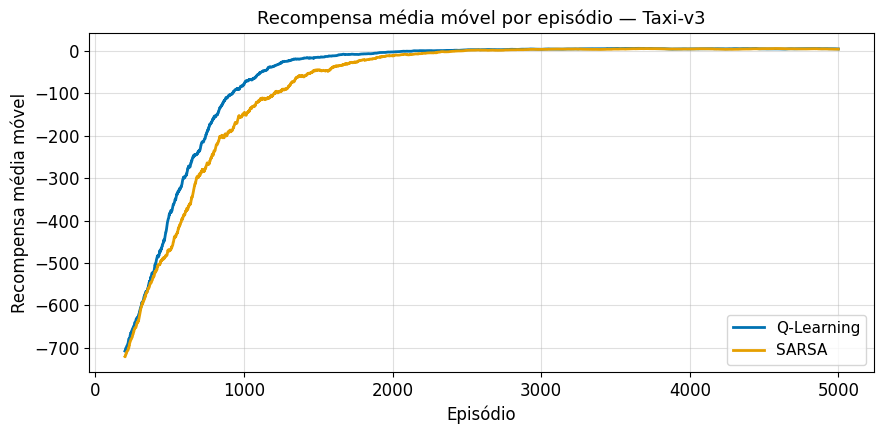

In [9]:
def media_movel(x, janela=200):
    if len(x) < janela:
        return x
    return np.convolve(x, np.ones(janela) / janela, mode='valid')

janela = 200
ma_r_ql = media_movel(recompensas_ql, janela)
ma_r_sa = media_movel(recompensas_sarsa, janela)

plt.figure(figsize=(9, 4.5))
plt.plot(np.arange(len(ma_r_ql)) + janela - 1, ma_r_ql, label='Q-Learning', linewidth=2)
plt.plot(np.arange(len(ma_r_sa)) + janela - 1, ma_r_sa, label='SARSA', linewidth=2)
plt.title('Recompensa média móvel por episódio — Taxi-v3')
plt.xlabel('Episódio')
plt.ylabel('Recompensa média móvel')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretação das curvas de recompensa

As curvas mostram que ambos os algoritmos aprendem ao longo do treinamento — a média móvel sobe de recompensas muito negativas (episódios iniciais com comportamento aleatório) para valores progressivamente menos negativos nos episódios finais.

A diferença entre Q-Learning e SARSA é sutil mas consistente. No Taxi-v3, ações ilegais — pegar ou largar o passageiro no lugar errado — geram penalidade de −10. Como o **SARSA inclui o custo real da exploração no alvo**, ele aprende que estados onde ações exploratórias perigosas podem ocorrer têm menor valor do que parecem, e tende a evitá-los com mais frequência.

O **Q-Learning** é mais otimista: aprende como se o agente sempre escolhesse a ação ótima a partir do próximo estado, ignorando que ações exploratórias com penalidade alta também serão executadas durante o treinamento. Isso pode gerar políticas mais agressivas, com desempenho variável dependendo da frequência com que ações exploratórias ruins ocorrem.

## Curvas do número médio de passos

O número de passos por episódio é uma métrica complementar importante. Políticas mais eficientes completam a tarefa em menos passos.

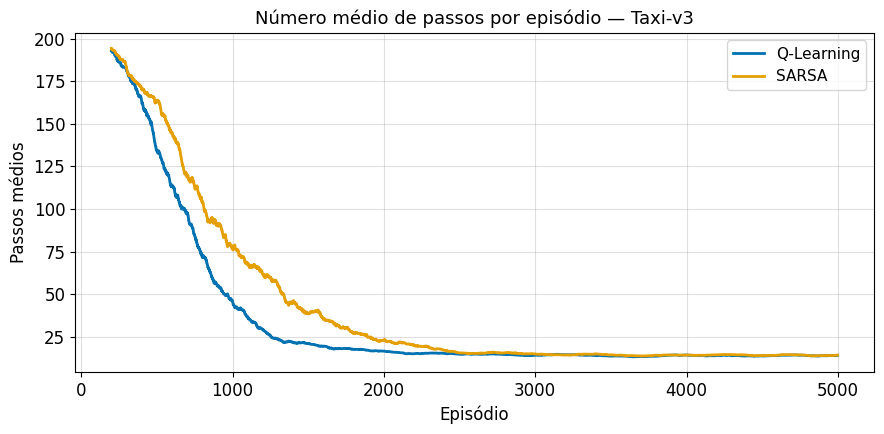

Resumo quantitativo (últimos 500 episódios):
  Q-Learning | recompensa: 5.31 | passos: 13.96
  SARSA      | recompensa: 4.92 | passos: 14.13


In [10]:
ma_s_ql = media_movel(passos_ql, janela)
ma_s_sa = media_movel(passos_sarsa, janela)

plt.figure(figsize=(9, 4.5))
plt.plot(np.arange(len(ma_s_ql)) + janela - 1, ma_s_ql, label='Q-Learning', linewidth=2)
plt.plot(np.arange(len(ma_s_sa)) + janela - 1, ma_s_sa, label='SARSA', linewidth=2)
plt.title('Número médio de passos por episódio — Taxi-v3')
plt.xlabel('Episódio')
plt.ylabel('Passos médios')
plt.legend()
plt.tight_layout()
plt.show()

print("Resumo quantitativo (últimos 500 episódios):")
print(f"  Q-Learning | recompensa: {recompensas_ql[-500:].mean():.2f} | passos: {passos_ql[-500:].mean():.2f}")
print(f"  SARSA      | recompensa: {recompensas_sarsa[-500:].mean():.2f} | passos: {passos_sarsa[-500:].mean():.2f}")

### Interpretação do número de passos

Políticas mais eficientes completam a tarefa com menos passos. Ambas as curvas mostram queda no número médio de passos por episódio ao longo do treinamento, à medida que cada algoritmo aprende a navegar mais diretamente até o passageiro e ao destino.

O resumo quantitativo (últimos 500 episódios) revela as performances finais de cada método. Q-Learning e SARSA tendem a convergir para resultados próximos no Taxi-v3. A diferença mais evidente aparece em ambientes onde penalidades exploratórias são mais frequentes ou severas.

A escolha entre os dois depende do custo real da exploração no ambiente: quando explorar é relativamente seguro, Q-Learning converge mais diretamente para a política ótima; quando explorar é custoso ou perigoso, SARSA aprende a ser mais cauteloso durante o próprio treinamento — vantagem que se torna mais visível ao testar a política em produção, não apenas em episódios de treinamento.

Decaimento padrão: recompensa média (últ. 500 ep) = 4.91
Epsilon fixo = 1.0 (sempre aleatório): recompensa média (últ. 500 ep) = -773.15
Epsilon fixo = 0.0 (sempre guloso): recompensa média (últ. 500 ep) = 7.84


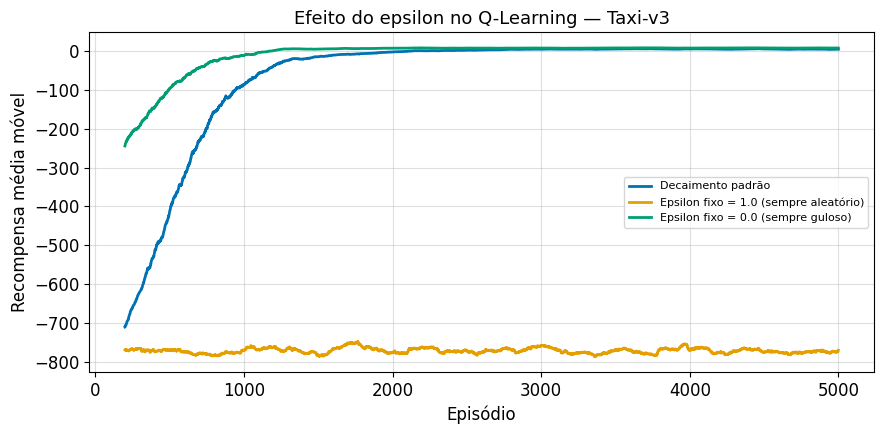

In [11]:
config_epsilon = {
    "Decaimento padrão": dict(eps_inicio=1.0, eps_fim=0.05, eps_decaimento=0.999),
    "Epsilon fixo = 1.0 (sempre aleatório)": dict(eps_inicio=1.0, eps_fim=1.0, eps_decaimento=1.0),
    "Epsilon fixo = 0.0 (sempre guloso)": dict(eps_inicio=0.0, eps_fim=0.0, eps_decaimento=1.0),
}

janela_d3 = 200
plt.figure(figsize=(9, 4.5))
for rotulo, kwargs in config_epsilon.items():
    _, log, _ = treinar_qlearning(env, episodios=5000, **kwargs)
    ma = media_movel(log, janela_d3)
    plt.plot(np.arange(len(ma)) + janela_d3 - 1, ma, label=rotulo, linewidth=2)
    print(f"{rotulo}: recompensa média (últ. 500 ep) = {log[-500:].mean():.2f}")

plt.title('Efeito do epsilon no Q-Learning — Taxi-v3')
plt.xlabel('Episódio')
plt.ylabel('Recompensa média móvel')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## ⚠️ O que pode dar errado: epsilon fixo sem decaimento

Quando epsilon não decai, o agente continua explorando aleatoriamente mesmo após ter aprendido uma política razoável. O experimento acima compara Q-Learning com decaimento padrão versus epsilon fixo em 1.0 (sempre aleatório) e epsilon fixo em 0.0 (sempre guloso desde o início).

**O que os resultados mostram:**
- *ε = 1.0 fixo:* recompensa nunca melhora — o agente sempre age aleatoriamente, nunca explota o que aprendeu.
- *ε = 0.0 fixo:* começa guloso, mas aprende mal porque a Q-table ainda está zerada — as primeiras ações gulosas não têm base real.
- *Decaimento:* explora no início (Q-table sendo preenchida) e explota ao final (Q-table com estimativas maduras) — o equilíbrio que produz o melhor resultado final.

## Preferências de ação em estados de exemplo

Como o Taxi possui 500 estados, visualizar toda a política não é prático. A tabela abaixo mostra, em alguns estados de exemplo, qual ação cada algoritmo prefere após o treinamento.

In [12]:
estados_exemplo = [0, 100, 250, 399]
print("Ações preferidas em estados de exemplo:")
for s in estados_exemplo:
    a_ql = int(np.argmax(Q_ql[s]))
    a_sa = int(np.argmax(Q_sarsa[s]))
    print(f"  Estado {s:>3} | Q-Learning: {nomes_acoes[a_ql]:>17} | SARSA: {nomes_acoes[a_sa]:>17}")

Ações preferidas em estados de exemplo:
  Estado   0 | Q-Learning:               Sul | SARSA:               Sul
  Estado 100 | Q-Learning:               Sul | SARSA:               Sul
  Estado 250 | Q-Learning:               Sul | SARSA:               Sul
  Estado 399 | Q-Learning:             Oeste | SARSA:               Sul


> **Nota:** Estes 4 estados são uma amostra dos 500 estados do Taxi-v3. Os algoritmos divergem principalmente em estados próximos a penalidades — que não aparecem necessariamente nesta seleção. Para ver a diferença completa entre as políticas:
> ```python
> np.sum(np.argmax(Q_ql, axis=1) != np.argmax(Q_sarsa, axis=1))
> ```
> Essa linha conta quantos dos 500 estados têm ações preferenciais diferentes entre Q-Learning e SARSA.

Os estados 0, 100 e 250 estão em regiões do mapa longe de penalidades diretas por ações ilegais. Nesses estados, Q-Learning e SARSA tendem a concordar porque a probabilidade de uma ação exploratória gerar a penalidade de −10 é baixa. A divergência aparece nos estados onde o passageiro está próximo de um ponto de coleta — justamente aqueles em que `epsilon_greedy` pode acidentalmente tentar "pegar o passageiro" no lugar errado.

## Bloco 4 — Interpretação pedagógica

A diferença entre Q-Learning e SARSA pode parecer pequena na fórmula (uma variável), mas tem implicações práticas:

- **Q-Learning** aprende como se o agente, a partir do próximo estado, sempre escolhesse a ação ótima. O treinamento é mais otimista. Em ambientes com penalidades severas por ações exploratórias (como ações ilegais no Taxi), isso pode fazer o agente aprender a se arriscar mais.

- **SARSA** inclui o custo real da exploração no alvo. O agente aprende que, durante o treinamento, ações exploratórias acontecerão — e incorpora esse custo na estimativa de valor. Isso tende a produzir políticas mais conservadoras durante a fase de aprendizado.

A comparação entre as curvas de recompensa e de passos torna essa diferença concreta: não basta ler as fórmulas, é preciso observar como o comportamento diverge ao longo do treinamento.

## Autoavaliação

<details>
<summary>Pergunta 1: Qual é a diferença na regra de atualização entre SARSA e Q-Learning?</summary>

**Resposta:** Q-Learning usa `r + γ·max_a' Q(s', a')` — o valor da melhor ação possível. SARSA usa `r + γ·Q(s', a')` onde `a'` é a ação que a política ε-greedy *efetivamente vai escolher*. Em Q-Learning `a'` é hipotético (max); em SARSA `a'` já foi sorteado antes da atualização.

**Por quê:** Essa única diferença determina se o algoritmo aprende sobre a política ótima (off-policy) ou sobre o comportamento real com exploração (on-policy).

</details>

<details>
<summary>Pergunta 2: Em que tipo de ambiente o SARSA tende a ser mais seguro que o Q-Learning?</summary>

**Resposta:** Em ambientes onde ações exploratórias têm custo ou risco concreto — como o Cliff Walking (onde exploração leva a quedas do penhasco) ou sistemas robóticos reais. O SARSA inclui o custo da exploração no alvo e aprende a evitar estados perigosos *durante* o treinamento. O Q-Learning aprende a política ótima sem considerar esse custo.

**Por quê:** O Q-Learning é otimista sobre o comportamento futuro (supõe que sempre agirá de forma gulosa), enquanto o SARSA é realista sobre o comportamento atual (inclui exploração no cálculo).

</details>

<details>
<summary>Pergunta 3: O que acontece se epsilon for muito alto ou muito baixo ao longo de todo o treinamento?</summary>

**Resposta:** Epsilon muito alto (ex.: 1.0 o tempo todo): o agente nunca explora o que aprendeu — a política nunca melhora porque ações aleatórias dominam. Epsilon muito baixo (ex.: 0.01 desde o início): o agente para de explorar cedo, fica preso em políticas subótimas e nunca descobre rotas melhores. O decaimento gradual equilibra exploração inicial com explotação posterior.

**Por quê:** Exploration-exploitation é um tradeoff fundamental em RL — qualquer extremo deteriora o aprendizado por razões opostas.

</details>

## Bloco 5 — Limites e transição

Q-Learning e SARSA são excelentes para ambientes com espaço de estados discreto e moderado, como o Taxi-v3. Porém, quando o número de estados cresce muito — ou quando o estado é **contínuo** (como posição, velocidade, ângulo) — a tabela Q deixa de ser viável.

Não é possível armazenar um valor explícito para cada combinação de estado e ação quando os estados são infinitos ou exponencialmente numerosos. Esse é o problema de escalabilidade que motiva o próximo notebook: substituir a tabela por uma **rede neural** — o que define o Deep Q-Network (DQN).

## Principais aprendizados

1. **SARSA vs Q-Learning** diferem em apenas uma variável do alvo: Q-Learning usa `max Q(s', *)` (off-policy); SARSA usa `Q(s', a')` onde `a'` é escolhida pela política atual (on-policy).
2. **On-policy** incorpora o custo real da exploração no aprendizado — SARSA aprende a ser mais cauteloso perto de penalidades como ações ilegais no Taxi-v3.
3. **Off-policy** aprende sobre a política ótima mesmo durante exploração — Q-Learning é mais otimista e pode convergir mais rápido em ambientes sem penalidade exploratória severa.
4. O **decaimento de epsilon** é crítico: sem ele, o agente continua explorando aleatoriamente e nunca explota o que aprendeu — conforme demonstrado pelo experimento de epsilon fixo.
5. **Espaço de estados discreto moderado** (Taxi: 500 estados) ainda é manejável com tabela Q — o próximo passo são espaços contínuos, onde tabelas falham e redes neurais se tornam necessárias.

## Glossário — termos introduzidos neste notebook

| Termo (EN) | Tradução (PT) | Descrição |
|---|---|---|
| SARSA | SARSA | State-Action-Reward-State-Action — algoritmo on-policy que usa a ação que será tomada no alvo. |
| on-policy | on-policy | Aprende sobre a política de comportamento atual, incluindo seu custo de exploração. |
| off-policy | off-policy | Aprende sobre a política ótima independentemente da política de comportamento. |
| behavior policy | política de comportamento | Política usada para coletar experiência durante o treinamento (geralmente ε-greedy). |
| target policy | política-alvo | Política sobre a qual o agente está aprendendo (pode diferir da política de comportamento). |

> Glossário completo do curso: [docs/glossario.md](../../docs/glossario.md)

## Leituras e referências

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2ª ed.). MIT Press. Cap. 6 (TD Learning), seção 6.4 (SARSA). Disponível em: http://incompleteideas.net/book/the-book-2nd.html. Acesso em: abril 2026.
- Rummery, G. A., & Niranjan, M. (1994). *On-line Q-learning using connectionist systems*. Technical Report CUED/F-INFENG/TR 166, Cambridge University.
- Farama Foundation. *Gymnasium — Taxi-v3*. Disponível em: https://gymnasium.farama.org/environments/toy_text/taxi/. Acesso em: abril 2026.